# Exercício Computacional: Gaussian Mixture Models e Algoritmo EM

## Objetivos
Neste exercício, vamos estudar **modelos de mistura Gaussiana (GMMs)** e o algoritmo **Expectation-Maximization (EM)**.

A atividade combina:
- interpretação probabilística de clustering
- implementação das etapas do EM
- visualização de responsabilidades
- comparação com agrupamentos mais rígidos

Usaremos:
- um dataset sintético bidimensional
- um segundo dataset real de baixa dimensão

## Orientações

- Use `numpy` e `matplotlib`
- Para datasets, você pode usar `sklearn.datasets`
- Complete as funções indicadas
- Interprete os gráficos
- Responda às questões conceituais ao final

Ao longo do notebook, vamos representar:
- dados por linhas: $X \in \mathbb{R}^{N \times D}$
- responsabilidades por linhas: $R \in \mathbb{R}^{N \times K}$

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans

np.random.seed(42)

---

## Parte 1 — Gerando e visualizando um dataset sintético

Vamos começar com um dataset bidimensional sintético com três grupos.

In [12]:
# Gere um dataset sintético bidimensional
# Sugestão:
# - usar make_blobs
# - N entre 300 e 500 pontos
# - centers = 3
# - cluster_std diferentes para deixar o problema mais interessante

X, y_true = make_blobs(
    n_samples=450,
    centers=[(-4, -1), (0, 4), (4, -2)],
    cluster_std=[1.4, 0.9, 1.2],
    random_state=42
)

print("Formato de X:", X.shape)
print("Classes verdadeiras disponíveis apenas para referência:", np.unique(y_true))

Formato de X: (450, 2)
Classes verdadeiras disponíveis apenas para referência: [0 1 2]


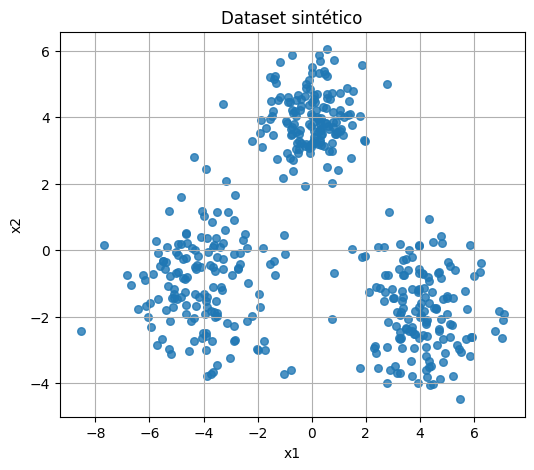

In [13]:
# Faça um scatter plot do dataset sintético

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset sintético')
plt.grid(True)
plt.show()

## Parte 2 — Funções auxiliares

Implemente funções básicas para o GMM:
1. densidade Gaussiana multivariada
2. inicialização dos parâmetros
3. cálculo da log-verossimilhança

In [14]:
def gaussian_pdf(X, mu, Sigma):
    '''
    Entrada:
        X: matriz N x D
        mu: vetor D
        Sigma: matriz D x D

    Saída:
        vetor com N densidades Gaussianas
    '''
    X = np.atleast_2d(X)
    D = X.shape[1]
    mu = np.asarray(mu)
    Sigma = np.asarray(Sigma)

    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        raise ValueError("A matriz de covariância deve ser definida positiva.")

    diff = X - mu
    Sigma_inv = np.linalg.inv(Sigma)
    maha = np.sum((diff @ Sigma_inv) * diff, axis=1)
    log_norm = -0.5 * (D * np.log(2 * np.pi) + logdet)
    log_pdf = log_norm - 0.5 * maha
    return np.exp(log_pdf)


def initialize_gmm(X, K, seed=0):
    '''
    Inicializa:
        pis: pesos da mistura, shape (K,)
        mus: médias, shape (K, D)
        Sigmas: covariâncias, shape (K, D, D)
    '''
    rng = np.random.default_rng(seed)
    N, D = X.shape

    pis = np.ones(K) / K

    idx = rng.choice(N, size=K, replace=False)
    mus = X[idx].copy()

    global_cov = np.cov(X, rowvar=False) + 1e-6 * np.eye(D)
    Sigmas = np.array([global_cov.copy() for _ in range(K)])

    return pis, mus, Sigmas


def log_likelihood(X, pis, mus, Sigmas):
    '''
    Retorna a log-verossimilhança do GMM
    '''
    K = len(pis)
    weighted = np.zeros((X.shape[0], K))

    for k in range(K):
        weighted[:, k] = pis[k] * gaussian_pdf(X, mus[k], Sigmas[k])

    return np.sum(np.log(np.sum(weighted, axis=1) + 1e-15))

## Parte 3 — Responsibilities (E-step)

Implemente o cálculo das responsabilidades:

$$
r_{nk} =
\frac{\pi_k \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma_k})}
{\sum_{j=1}^K \pi_j \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}
$$

Lembre:
- cada linha da matriz $\mathbf{R}$ (que contém as responsabilidades) deve somar 1
- cada entrada deve ser não negativa

In [15]:
def expectation_step(X, pis, mus, Sigmas):
    '''
    Retorna:
        R: matriz N x K de responsabilidades
    '''
    N = X.shape[0]
    K = len(pis)
    weighted = np.zeros((N, K))

    for k in range(K):
        weighted[:, k] = pis[k] * gaussian_pdf(X, mus[k], Sigmas[k])

    normalizer = np.sum(weighted, axis=1, keepdims=True) + 1e-15
    R = weighted / normalizer
    return R

In [16]:
# Teste inicial das responsabilidades

K = 3
pis, mus, Sigmas = initialize_gmm(X, K, seed=42)
R = expectation_step(X, pis, mus, Sigmas)

print("Formato de R:", R.shape)
print("Soma das responsabilidades nas 5 primeiras linhas:")
print(np.sum(R[:5], axis=1))

Formato de R: (450, 3)
Soma das responsabilidades nas 5 primeiras linhas:
[1. 1. 1. 1. 1.]


## Parte 4 — Atualização dos parâmetros (M-step)

Implemente:
- pesos $ \pi_k $
- médias $ \mu_k $
- covariâncias $ \Sigma_k $

Use as fórmulas:

$$
N_k = \sum_{n=1}^{N} r_{nk}
$$

$$
\boldsymbol{\mu}_k = \frac{1}{N_k}\sum_{n=1}^{N} r_{nk} \mathbf{x}_n
$$

$$
\boldsymbol{\Sigma}_k = \frac{1}{N_k}\sum_{n=1}^{N} r_{nk}(\mathbf{x}_n-\boldsymbol{\mu}_k)(\mathbf{x}_n-\boldsymbol{\mu}_k)^\top
$$

$$
\pi_k = \frac{N_k}{N}
$$

In [17]:
def maximization_step(X, R, reg=1e-6):
    '''
    Entrada:
        X: matriz N x D
        R: matriz N x K
        reg: termo de regularização para a diagonal da covariância

    Saída:
        pis, mus, Sigmas
    '''
    N, D = X.shape
    K = R.shape[1]

    Nk = np.sum(R, axis=0) + 1e-15
    pis = Nk / N
    mus = (R.T @ X) / Nk[:, None]

    Sigmas = np.zeros((K, D, D))
    for k in range(K):
        diff = X - mus[k]
        Sigmas[k] = (R[:, k][:, None] * diff).T @ diff / Nk[k]
        Sigmas[k] += reg * np.eye(D)

    return pis, mus, Sigmas

In [18]:
# Teste da etapa M

pis_new, mus_new, Sigmas_new = maximization_step(X, R)

print("Pesos:", pis_new)
print("Formato das médias:", mus_new.shape)
print("Formato das covariâncias:", Sigmas_new.shape)
print("Soma dos pesos:", np.sum(pis_new))

Pesos: [0.16349817 0.24798955 0.58851228]
Formato das médias: (3, 2)
Formato das covariâncias: (3, 2, 2)
Soma dos pesos: 0.9999999999988664


## Parte 5 — Uma iteração completa do EM

Agora junte as duas etapas:
1. E-step
2. M-step
3. cálculo da log-verossimilhança

In [19]:
# Execute uma iteração do EM a partir da inicialização

pis, mus, Sigmas = initialize_gmm(X, K=3, seed=123)

ll_before = log_likelihood(X, pis, mus, Sigmas)
R = expectation_step(X, pis, mus, Sigmas)
pis, mus, Sigmas = maximization_step(X, R)
ll_after = log_likelihood(X, pis, mus, Sigmas)

print("Log-verossimilhança antes:", ll_before)
print("Log-verossimilhança depois:", ll_after)

Log-verossimilhança antes: -2417.5473629208855
Log-verossimilhança depois: -2029.9113126031464


## Parte 6 — Implementando o algoritmo EM completo

Implemente um laço iterativo para o EM.

### Sugestões
- armazenar a log-verossimilhança a cada iteração
- usar tolerância para critério de parada
- parar se o ganho for muito pequeno

In [20]:
def fit_gmm_em(X, K, max_iter=100, tol=1e-4, seed=0):
    '''
    Ajusta um GMM por EM.

    Retorna:
        pis, mus, Sigmas, R, ll_history
    '''
    pis, mus, Sigmas = initialize_gmm(X, K, seed=seed)
    ll_history = []

    for _ in range(max_iter):
        R = expectation_step(X, pis, mus, Sigmas)
        pis, mus, Sigmas = maximization_step(X, R)
        ll = log_likelihood(X, pis, mus, Sigmas)
        ll_history.append(ll)

        if len(ll_history) > 1 and abs(ll_history[-1] - ll_history[-2]) < tol:
            break

    R = expectation_step(X, pis, mus, Sigmas)
    return pis, mus, Sigmas, R, ll_history

In [21]:
# Ajuste o GMM ao dataset sintético

pis, mus, Sigmas, R, ll_history = fit_gmm_em(X, K=3, max_iter=200, tol=1e-5, seed=42)

print("Pesos finais:", pis)
print("Médias finais:\n", mus)
print("Última log-verossimilhança:", ll_history[-1])

Pesos finais: [0.33307761 0.33168282 0.33523957]
Médias finais:
 [[ 4.04474575 -1.84550784]
 [-4.04675671 -0.99977227]
 [-0.00891236  3.95339318]]
Última log-verossimilhança: -1872.0038736441797


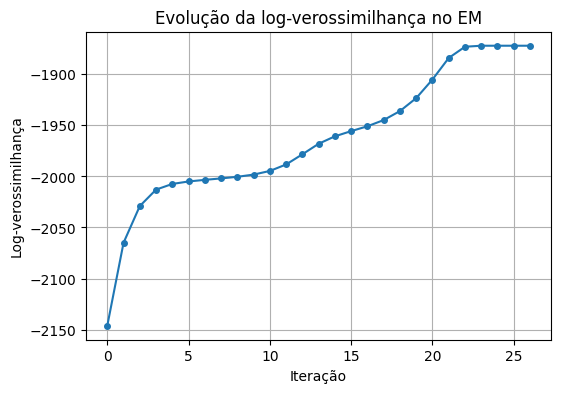

In [22]:
# Plote a log-verossimilhança ao longo das iterações

plt.figure(figsize=(6, 4))
plt.plot(ll_history, marker='o', linewidth=1.5, markersize=4)
plt.xlabel('Iteração')
plt.ylabel('Log-verossimilhança')
plt.title('Evolução da log-verossimilhança no EM')
plt.grid(True)
plt.show()

## Parte 7 — Visualizando os clusters e as responsabilidades

Agora vamos usar o GMM ajustado para visualizar:
1. atribuição suave
2. atribuição dura (argmax das responsabilidades)
3. médias aprendidas

In [23]:
# Atribuição dura a partir das responsabilidades
labels_gmm = np.argmax(R, axis=1)

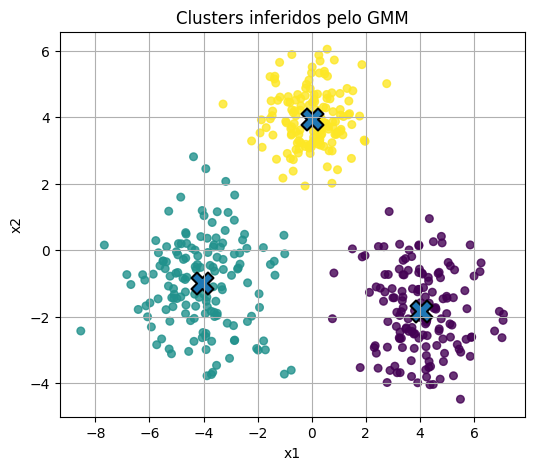

In [24]:
# Scatter plot colorido pela atribuição dura do GMM
# Marque também as médias aprendidas

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_gmm, s=30, alpha=0.8)
plt.scatter(mus[:, 0], mus[:, 1], marker='X', s=250, linewidths=1.5, edgecolors='black')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Clusters inferidos pelo GMM')
plt.grid(True)
plt.show()

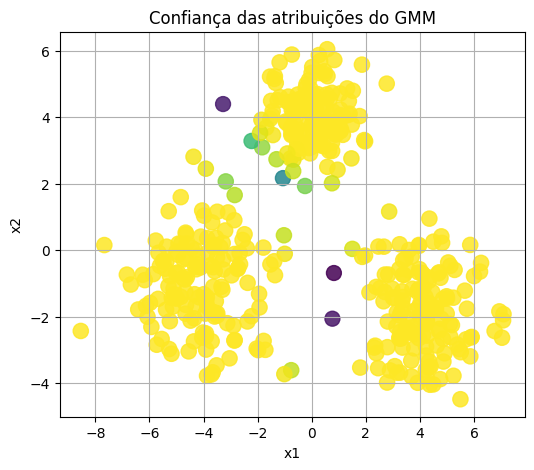

In [25]:
# Visualize a confiança da atribuição:
# Sugestão: usar max(R, axis=1) como transparência, tamanho ou cor auxiliar

confidence = np.max(R, axis=1)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=confidence, s=40 + 80 * confidence, alpha=0.85)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Confiança das atribuições do GMM')
plt.grid(True)
plt.show()

## Parte 9 — Segundo dataset: Iris

Vamos repetir a ideia em um dataset real.

### Tarefas
1. carregar o dataset Iris
2. selecionar duas features para visualização
3. ajustar um GMM com \(K=3\)
4. comparar classes reais e clusters inferidos

In [26]:
iris = load_iris()
X_iris = iris.data[:, :2]   # use apenas duas features para facilitar a visualização
y_iris = iris.target

print("Formato de X_iris:", X_iris.shape)
print("Classes:", np.unique(y_iris))
print("Features usadas:", iris.feature_names[:2])

Formato de X_iris: (150, 2)
Classes: [0 1 2]
Features usadas: ['sepal length (cm)', 'sepal width (cm)']


In [27]:
# Ajuste o GMM no dataset Iris

pis_i, mus_i, Sigmas_i, R_i, ll_i = fit_gmm_em(X_iris, K=3, max_iter=200, tol=1e-5, seed=42)

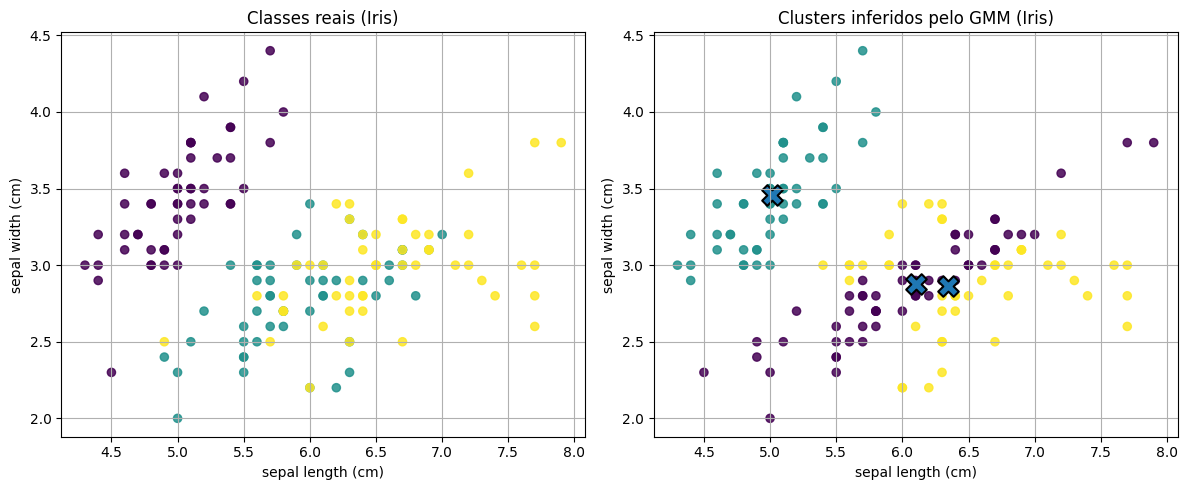

In [28]:
# Compare:
# 1. classes reais
# 2. clusters inferidos pelo GMM

labels_iris_gmm = np.argmax(R_i, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, s=35, alpha=0.85)
axes[0].set_title('Classes reais (Iris)')
axes[0].set_xlabel(iris.feature_names[0])
axes[0].set_ylabel(iris.feature_names[1])
axes[0].grid(True)

axes[1].scatter(X_iris[:, 0], X_iris[:, 1], c=labels_iris_gmm, s=35, alpha=0.85)
axes[1].scatter(mus_i[:, 0], mus_i[:, 1], marker='X', s=220, linewidths=1.5, edgecolors='black')
axes[1].set_title('Clusters inferidos pelo GMM (Iris)')
axes[1].set_xlabel(iris.feature_names[0])
axes[1].set_ylabel(iris.feature_names[1])
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Parte 10 — Questões conceituais

Responda:

1. Qual é a diferença entre atribuição dura e atribuição suave?
2. O que representam as responsabilidades $r_{nk}$?
3. Por que o EM é iterativo?
4. Por que a log-verossimilhança tende a aumentar a cada iteração?
5. O que acontece se a inicialização dos parâmetros for ruim?
6. Como fazer para ajustar o número de componentes do GMM?

Respostas:

1. **Atribuição dura** associa cada ponto a um único cluster, normalmente escolhendo o componente com maior responsabilidade (por exemplo, via `argmax`). **Atribuição suave** mantém, para cada ponto, uma distribuição de probabilidades entre os clusters. Assim, na atribuição suave um ponto pode pertencer parcialmente a mais de um grupo, o que é especialmente útil quando ele está perto de regiões de sobreposição.

2. As responsabilidades $r_{nk}$ representam a probabilidade posterior de que a observação $x_n$ tenha sido gerada pelo componente gaussiano $k$, dado o conjunto atual de parâmetros do modelo. Em outras palavras, elas medem o grau de pertencimento de cada ponto a cada cluster.

3. O EM é iterativo porque existe uma dependência circular no problema: para estimar bem os parâmetros do GMM, precisamos saber a qual componente cada ponto pertence; mas, para estimar essas pertenças probabilísticas, precisamos já conhecer os parâmetros. O algoritmo resolve isso alternando entre estimar responsabilidades (E-step) e atualizar parâmetros (M-step), refinando gradualmente a solução.

4. A log-verossimilhança tende a aumentar porque cada passo do EM é construído para não piorar o ajuste atual. No E-step, calculamos a melhor atribuição probabilística possível com os parâmetros fixos; no M-step, recalculamos os parâmetros que maximizam a esperança da log-verossimilhança completa. Por isso, em geral, o algoritmo produz uma sequência não decrescente da log-verossimilhança.

5. Se a inicialização for ruim, o algoritmo pode convergir para um **máximo local** ruim, produzir clusters mal posicionados, covariâncias inadequadas ou até componentes praticamente vazios. Por isso, na prática, é comum rodar o EM várias vezes com diferentes sementes e comparar a log-verossimilhança final ou algum critério de seleção.

6. O número de componentes do GMM pode ser ajustado comparando diferentes valores de $K$. Para isso, pode-se usar critérios como **AIC** e **BIC**, validação em conjunto de teste/validação, interpretação do problema ou conhecimento prévio do domínio. Em muitos casos, o BIC é bastante usado porque penaliza modelos excessivamente complexos.